In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score ,root_mean_squared_error
import warnings

In [2]:
data =pd.read_csv('Social_Network_Ads.csv')
data.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [3]:
x =data.iloc[:, [2,3]].values
y =data.iloc[:,4].values
x_train ,x_test ,y_train ,y_test =train_test_split(x,y ,train_size=0.8 ,random_state=10)


In [4]:
from sklearn.preprocessing import StandardScaler
sc_x = StandardScaler()
x_train =sc_x.fit_transform(x_train)
x_test = sc_x.transform(x_test)


In [5]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)



In [12]:
from sklearn.metrics import confusion_matrix,accuracy_score ,precision_score,f1_score,roc_auc_score,recall_score
cm =confusion_matrix(y_test ,y_pred)
cm

array([[48,  4],
       [ 5, 23]])

In [9]:
tp ,fn ,fp ,tn = cm.ravel()
print(tn ,fp ,fn ,tp)

23 5 4 48


In [13]:
accuracy_score_ =accuracy_score(y_test, y_pred)
 
recall_score_=recall_score(y_test, y_pred)
precision_score_=precision_score(y_test, y_pred)
f1_score_=f1_score(y_test, y_pred)
print('accuracy_score_',accuracy_score_)
print('recall_score_',recall_score_)
print('precision_score_',precision_score_)
print('f1_score_',f1_score_)

accuracy_score_ 0.8875
recall_score_ 0.8214285714285714
precision_score_ 0.8518518518518519
f1_score_ 0.8363636363636363


C:\Users\Administrator\AppData\Local\Temp\ipykernel_12928\4145977070.py:15: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_Set[Y_Set == j, 0], X_Set[Y_Set == j,1],


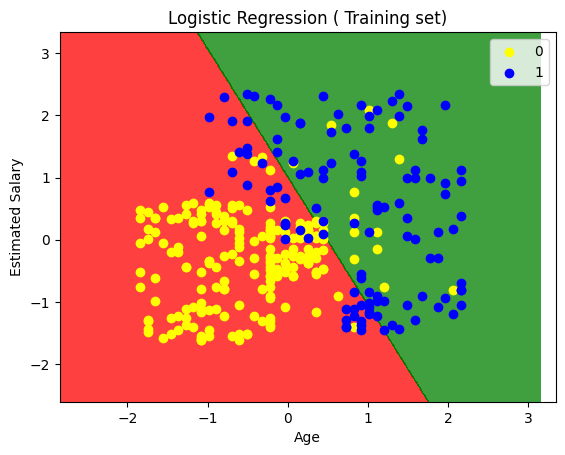

In [15]:
# Visualising the Training set results
 
from matplotlib.colors import ListedColormap
X_Set, Y_Set = x_train, y_train
X1, X2 = np.meshgrid(np.arange(start = X_Set[:,0].min() -1, stop = X_Set[:, 0].max() +1, step = 0.01),
                     np.arange(start = X_Set[:,1].min() -1, stop = X_Set[:, 1].max() +1, step = 0.01))
 
 
plt.contourf(X1,X2, model.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
 
plt.xlim(X1.min(), X2.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(Y_Set)):
    plt.scatter(X_Set[Y_Set == j, 0], X_Set[Y_Set == j,1],
                c = ListedColormap(('yellow', 'blue'))(i), label = j)
plt.title('Logistic Regression ( Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()